Loading data...
Data loaded!
X shape: (400, 4096)
y shape: (400,)
Unique labels: {np.int64(0), np.int64(1)}
Training model...
Training done!
Accuracy: 0.55


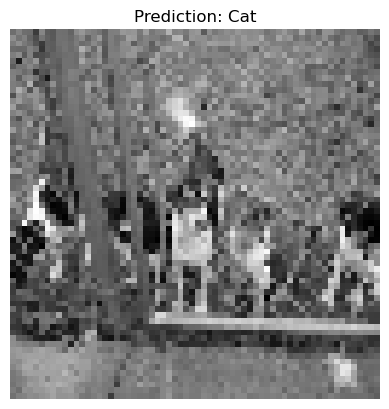

In [3]:
import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
import warnings

# 🔕 Ignore warnings (like emoji/font warnings)
warnings.filterwarnings("ignore")

from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 🔴 UPDATE THIS PATH
DATA_PATH = r"C:\Users\Chatur Kumar\Downloads\dogs vs cats\dogs vs cats\train\train"

IMG_SIZE = 64

def load_data_flat(path, limit_per_class=200):
    data = []
    labels = []

    files = os.listdir(path)

    # Separate cats and dogs
    cats = [f for f in files if "cat" in f.lower()]
    dogs = [f for f in files if "dog" in f.lower()]

    # Balance dataset
    selected_files = cats[:limit_per_class] + dogs[:limit_per_class]
    random.shuffle(selected_files)

    for file in selected_files:
        img_path = os.path.join(path, file)

        if "cat" in file.lower():
            label = 0
        elif "dog" in file.lower():
            label = 1
        else:
            continue

        try:
            img = cv2.imread(img_path)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            data.append(img.flatten())
            labels.append(label)
        except:
            pass

    return np.array(data), np.array(labels)

# 🚀 Load data
print("Loading data...")
X, y = load_data_flat(DATA_PATH, limit_per_class=200)

print("Data loaded!")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique labels:", set(y))

# Safety check
if len(set(y)) < 2:
    raise ValueError("Only one class found! Check dataset.")

# Normalize
X = X / 255.0

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 🔥 Train SVM (fast)
print("Training model...")
model = svm.SVC(kernel='linear')   # fast & stable
model.fit(X_train, y_train)
print("Training done!")

# Accuracy
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

# 🔍 Visual prediction
idx = np.random.randint(0, len(X_test))
img = X_test[idx].reshape(IMG_SIZE, IMG_SIZE)
pred = model.predict([X_test[idx]])[0]

label = "Dog" if pred == 1 else "Cat"

plt.imshow(img, cmap='gray')
plt.title(f"Prediction: {label}")
plt.axis('off')
plt.show()